# EDA — Spam Email Classification
Exploratory Data Analysis on the raw `emails.csv` dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/emails.csv')
df.shape

(5728, 2)

## Basic structure

In [2]:
df.dtypes

text      str
spam    int64
dtype: object

In [3]:
df.head(3)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


## Missing values & duplicates

In [4]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(33)

## Target distribution
The dataset is imbalanced: roughly 76% Ham vs 24% Spam.

In [6]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

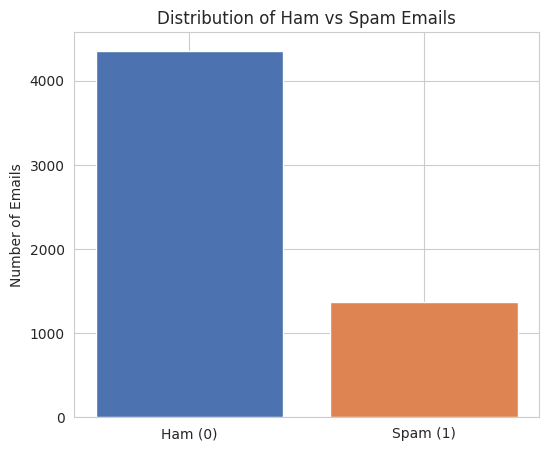

In [7]:
counts = df['spam'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(['Ham (0)','Spam (1)'], counts.values, color=['#4C72B0','#DD8452'])
plt.title('Distribution of Ham vs Spam Emails')
plt.ylabel('Number of Emails')
plt.show()

## Text length characteristics

In [8]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df[['text_length','word_count']].describe()

,text_length,word_count
count,5728.000000,5728.000000
mean,1556.768680,326.848638
std,2042.649812,418.777435
min,13.000000,2.000000
25%,508.750000,101.000000
50%,979.000000,210.000000
75%,1894.250000,401.000000
max,43952.000000,8477.000000


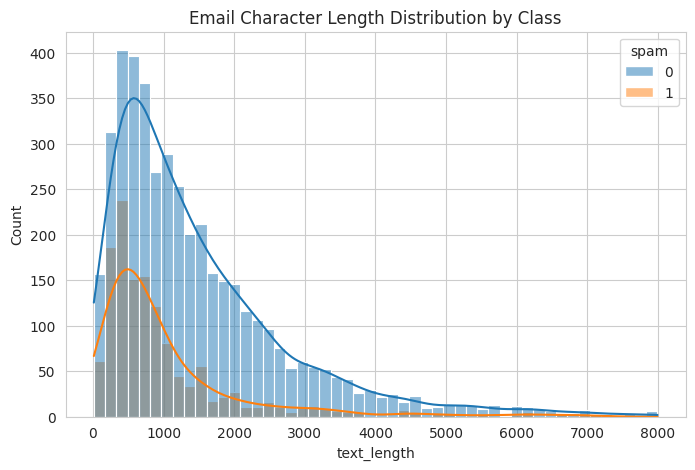

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df[df['text_length']<8000], x='text_length', hue='spam', bins=50, kde=True)
plt.title('Email Character Length Distribution by Class')
plt.show()

**Interpretation:** Spam emails tend to have a different length profile than legitimate emails; most emails (both classes) fall under 2,000 characters, with a long tail of very long messages.

## Most frequent words by class

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
for label, name in [(1,'Spam'), (0,'Ham')]:
    texts = df[df['spam']==label]['text']
    cv = CountVectorizer(stop_words='english', max_features=15)
    X = cv.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    words = cv.get_feature_names_out()
    order = freqs.argsort()[::-1]
    print(name, ':', [words[i] for i in order])

Spam : ['subject', 'com', 'business', 'company', 'email', 'information', 'money', 'free', 'http', 'mail', '000', 'click', 'just', 'time', 'new']


Ham : ['enron', 'ect', 'subject', 'vince', 'hou', '2000', 'kaminski', 'com', 'cc', 'pm', '2001', 'research', 'thanks', 'know', 'group']
